# Principal Component Analysis (PCA) – From Scratch

In this notebook, we implement Principal Component Analysis (PCA)
from scratch to reduce dimensionality while preserving maximum variance.


In [1]:
import numpy as np
import matplotlib.pyplot as plt


In [2]:
np.random.seed(0)

X = np.random.multivariate_normal(
    mean=[0, 0],
    cov=[[3, 1], [1, 2]],
    size=300
)


# Visualize data

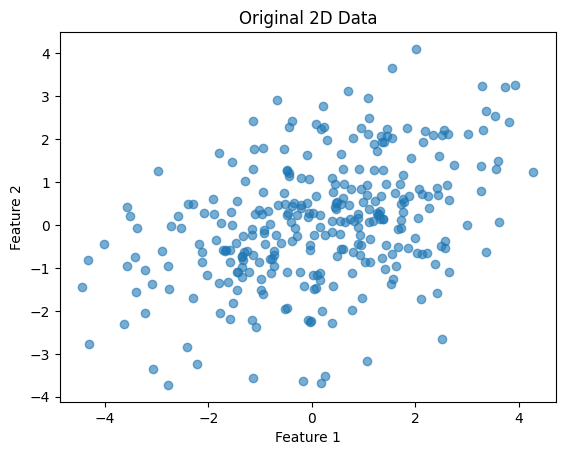

In [3]:
plt.scatter(X[:, 0], X[:, 1], alpha=0.6)
plt.title("Original 2D Data")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()


## PCA Intuition

PCA finds new axes (principal components) that:
- Capture maximum variance
- Are orthogonal to each other
- Reduce dimensionality with minimal information loss


In [4]:
# mean normalization
X_mean = np.mean(X, axis=0)
X_centered = X - X_mean


In [5]:
# Compute Covariance Matrix
cov_matrix = np.cov(X_centered, rowvar=False)
cov_matrix


array([[3.07019001, 1.04140979],
       [1.04140979, 2.01231741]])

In [6]:
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)


In [7]:
# Sort Eigenvectors

idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]


In [8]:
# Variance Ratio
explained_variance_ratio = eigenvalues / np.sum(eigenvalues)
explained_variance_ratio

array([0.7298149, 0.2701851])

We select the top-k eigenvectors that explain most variance.

In [9]:
k = 1
W = eigenvectors[:, :k]

X_reduced = X_centered @ W


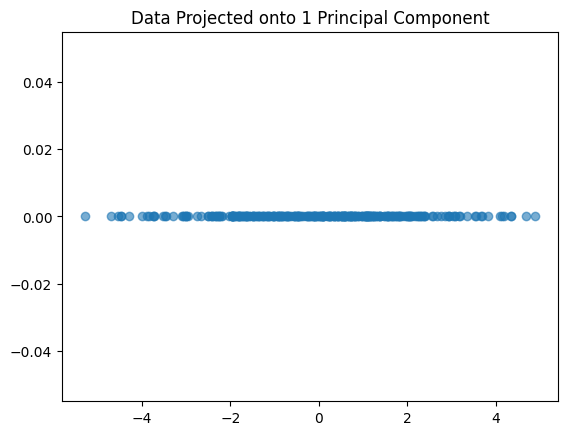

In [10]:
# Visualize Reduced Data
plt.scatter(X_reduced, np.zeros_like(X_reduced), alpha=0.6)
plt.title("Data Projected onto 1 Principal Component")
plt.show()

In [11]:
# Compare Original vs Reconstructed
X_reconstructed = X_reduced @ W.T + X_mean


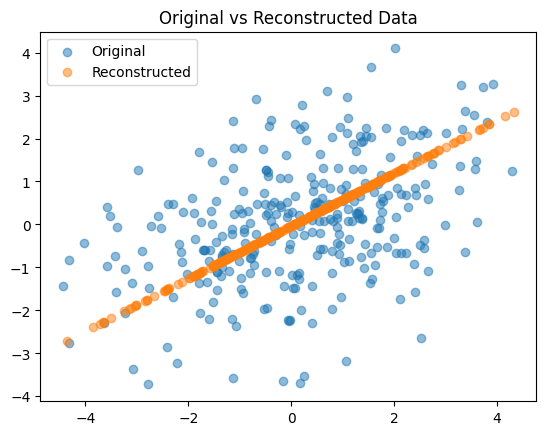

In [12]:
# Compare Original vs Reconstructed
plt.scatter(X[:, 0], X[:, 1], label="Original", alpha=0.5)
plt.scatter(X_reconstructed[:, 0], X_reconstructed[:, 1],
            label="Reconstructed", alpha=0.5)
plt.legend()
plt.title("Original vs Reconstructed Data")
plt.show()


## Why PCA Matters

- Reduces dimensionality
- Speeds up training
- Removes noise
- Enables visualization of high-dimensional data
